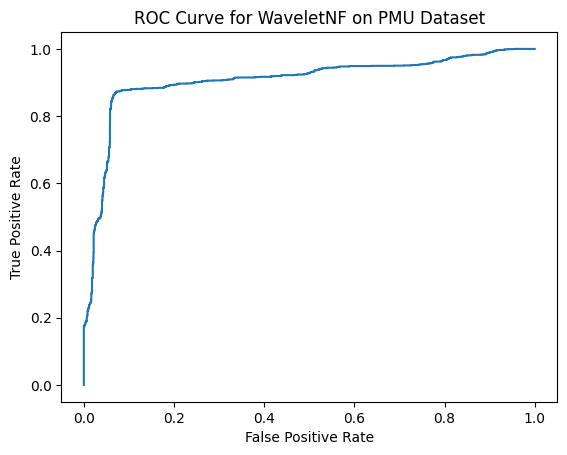

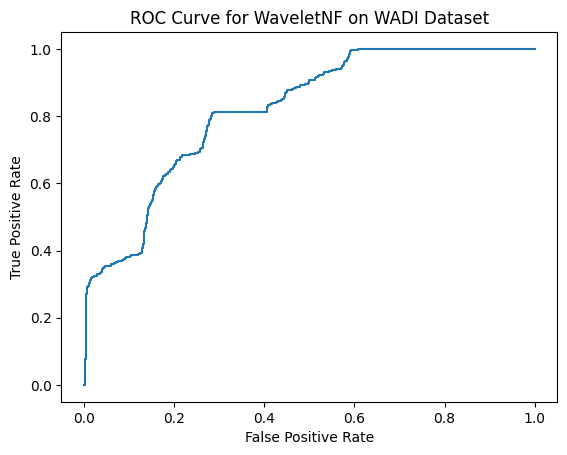

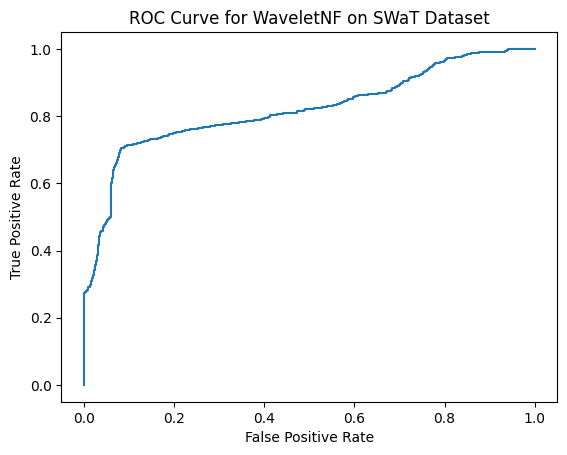

In [30]:
from utils import *
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

results = dotdict({})
for model in ["WaveletNF", "WENFW", "WENFA", "RealNVP", "coif1", "coif2", "db1", "db2", "haar", "k0.05", "k0.10", "k0.15", "k0.20", "k0.25", "window16", "window32", "window48","window64", "window96"]:

    model_results = dotdict({})

    for dataset in ["PMU", "wadi","swat"]:
        model_results[dataset] = dotdict({"AUC": 0, "AUC_std": 0})

        auc_values = []
        prec_values = []
        aucpr_values = []
        auc = 0
        recall_values = []
        f1_values = []
        infer_time_values = []
        parameter_values = 0
        train_time = []
        densities = []
        if model in ["k0.05", "k0.10", "k0.15", "k0.20", "k0.25", "db1", "db2", "coif1", "coif2", "haar", "window16", "window32", "window48","window64", "window96"]:
            seeds = [6, 7, 8]
        else:
            seeds = [6, 7, 8, 9, 10]
        for seed in seeds:
            log = load_json(f"../log/{model}_{dataset}_seed_{seed}/test_results")
            log = dotdict(log)
            auc_values.append(log["AUC"])
            if log["AUC"] > auc:
                auc = log["AUC"]
            tpr = log["TPR"]
            fpr = log["FPR"]
            if model == "WaveletNF":
                if dataset == "swat" and seed ==7 :
                    df = pd.DataFrame([fpr, tpr]).T.round(4)
                    df.columns = [["x", "y"]]
                    df.to_csv(f"ROC_{model}_{dataset}.csv", index=False)
                    fig = plt.figure()
                    plt.plot(fpr, tpr, label=f"{model} on {dataset} (AUC={log['AUC']:.4f})")
                    plt.title("ROC Curve for WaveletNF on SWaT Dataset")
                    plt.xlabel("False Positive Rate")
                    plt.ylabel("True Positive Rate")
                    plt.savefig("../figures/ROC_WaveletNF_swat.png", dpi=300, bbox_inches='tight')
                    
                if dataset == "wadi" and seed == 6:
                    df = pd.DataFrame([fpr, tpr]).T.round(4)
                    df.columns = [["x", "y"]]
                    df.to_csv(f"ROC_{model}_{dataset}.csv", index=False)
                    fig = plt.figure()
                    plt.plot(fpr, tpr, label=f"{model} on {dataset} (AUC={log['AUC']:.4f})")
                    plt.title("ROC Curve for WaveletNF on WADI Dataset")
                    plt.xlabel("False Positive Rate")
                    plt.ylabel("True Positive Rate")
                    plt.savefig("../figures/ROC_WaveletNF_wadi.png", dpi=300, bbox_inches='tight')

                if dataset == "PMU" and seed == 6:
                    df = pd.DataFrame([fpr, tpr]).T.round(4)
                    df.columns = [["x", "y"]]
                    df.to_csv(f"ROC_{model}_{dataset}.csv", index=False)
                    fig = plt.figure()
                    plt.plot(fpr, tpr, label=f"{model} on {dataset} (AUC={log['AUC']:.4f})")
                    plt.title("ROC Curve for WaveletNF on PMU Dataset")
                    plt.xlabel("False Positive Rate")
                    plt.ylabel("True Positive Rate")
                    plt.savefig("../figures/ROC_WaveletNF_PMU.png", dpi=300, bbox_inches='tight')

            infer_time_values.append(log["Inference_Time"])
            densities.append(log["Log-Density"])
            parameter_values = log["Parameters"]
            prec_values.append(log["Precision"])
            recall_values.append(log["Recall"])
            f1_values.append(log["F1"])


            log = load_json(f"../log/{model}_{dataset}_seed_{seed}/results")
            log = dotdict(log)
            train_time.append(log["train_time"])
            

        
        model_results[dataset].AUC = np.mean(auc_values)
        model_results[dataset].AUC_std = np.std(auc_values)
        model_results[dataset].Precision = np.mean(prec_values)
        model_results[dataset].Precision_std = np.std(prec_values)
        model_results[dataset].Recall = np.mean(recall_values)
        model_results[dataset].Recall_std = np.std(recall_values)
        model_results[dataset].F1 = np.mean(f1_values)
        model_results[dataset].F1_std = np.std(f1_values)

        model_results[dataset].Parameters = parameter_values
        model_results[dataset].Time = np.mean(infer_time_values)
        model_results[dataset].Train_Time = np.mean(train_time)
        model_results[dataset].Train_Time_std = np.std(train_time)
        model_results[dataset].Time_std = np.std(infer_time_values)
    
    results[model] = model_results


In [ ]:
print("WENFlow Detection and Efficiency Results (Tables 4, 5):")
print("================================")
print("PMU:")
results.WaveletNF.PMU

WENFlow Detection and Efficiency Results:
PMU:


{'AUC': 0.9045936681084573,
 'AUC_std': 0.009104382585596893,
 'Precision': 0.6704550380954484,
 'Precision_std': 0.009848909916697447,
 'Recall': 0.921334172435494,
 'Recall_std': 0.010841966251659162,
 'F1': 0.7760010227208178,
 'F1_std': 0.0039022938101578044,
 'Parameters': 36769,
 'Time': 0.00653570937924087,
 'Train_Time': 294.4002420425415,
 'Train_Time_std': 18.956254314703838,
 'Time_std': 0.00018005256914864948}

In [15]:
print("WADI:")
results.WaveletNF.wadi

WADI:


{'AUC': 0.8180062433792994,
 'AUC_std': 0.004617997972113245,
 'Precision': 0.5254256901885281,
 'Precision_std': 0.007660439004264528,
 'Recall': 0.8046647230320699,
 'Recall_std': 0.0,
 'F1': 0.6357012113847506,
 'F1_std': 0.005606520219444896,
 'Parameters': 20909,
 'Time': 0.01066968371825559,
 'Train_Time': 17.396000719070436,
 'Train_Time_std': 0.03212785826012879,
 'Time_std': 0.00037299022776612916}

In [16]:
print("SWaT:")
results.WaveletNF.swat

SWaT:


{'AUC': 0.809235244359512,
 'AUC_std': 0.01523313163187383,
 'Precision': 0.5564299780530442,
 'Precision_std': 0.03134892013980977,
 'Recall': 0.8007590132827325,
 'Recall_std': 0.16267958443531544,
 'F1': 0.6529899425971577,
 'F1_std': 0.07417611530862459,
 'Parameters': 13517,
 'Time': 0.018225668375897737,
 'Train_Time': 75.52939071655274,
 'Train_Time_std': 0.97135871599419,
 'Time_std': 0.0005051374641325656}

In [17]:
print("WENFlow Ablation Results (Table 6):")
print("================================")
print("WF\A PMU:")
results.WENFA.PMU

print("WF\A WADI:")
results.WENFA.wadi

print("WF\A SWaT:")
results.WENFA.swat

print("WF\W PMU:")
results.WENFW.PMU

print("WF\W WADI:")
results.WENFW.wadi

print("WF\W SWaT:")
results.WENFW.swat

print("RealNVP PMU:")
results.RealNVP.PMU 

print("RealNVP WADI:")
results.RealNVP.wadi

print("RealNVP SWaT:")
results.RealNVP.swat

WENFlow Ablation Results (Table 6):
WF\A PMU:
WF\A WADI:
WF\A SWaT:
WF\W PMU:
WF\W WADI:
WF\W SWaT:
RealNVP PMU:
RealNVP WADI:
RealNVP SWaT:


{'AUC': 0.7559222042764203,
 'AUC_std': 0.011326788120467026,
 'Precision': 0.4188843234087418,
 'Precision_std': 0.022648143774649885,
 'Recall': 0.23719165085388996,
 'Recall_std': 0.03255804264064852,
 'F1': 0.30153595282400086,
 'F1_std': 0.027496515040635987,
 'Parameters': 4044,
 'Time': 0.0037872518723209695,
 'Train_Time': 1.523036813735962,
 'Train_Time_std': 0.02977287144767668,
 'Time_std': 1.0787346261576092e-05}

In [ ]:
plot_sensitivity_analysis(results):


Sensitivity Analysis Figures (Figures 6, 7, 8):
Sensitivity Analysis on K:


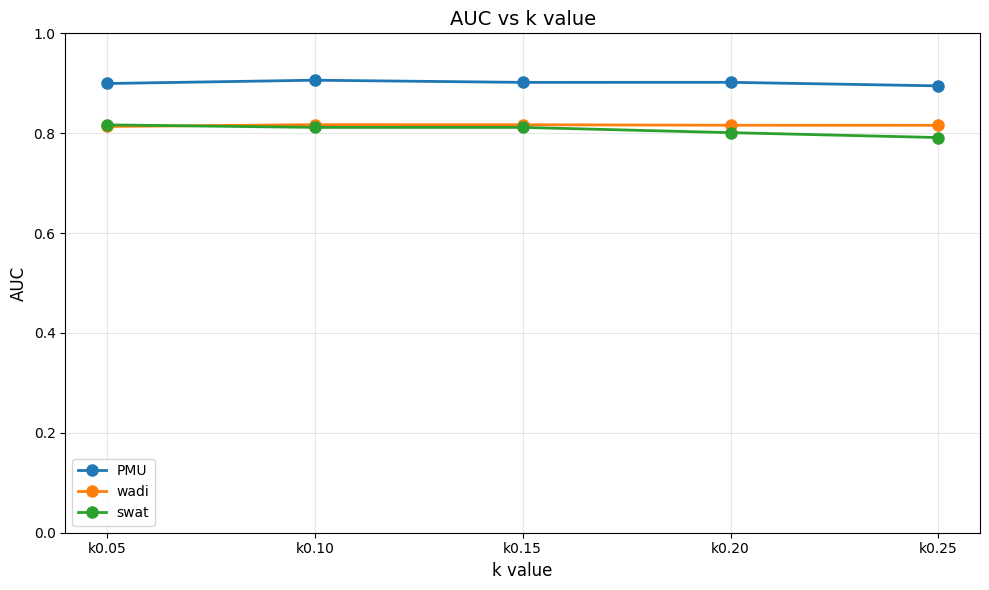

In [ ]:
print("Sensitivity Analysis Figures (Figures 6, 7, 8):")
print("================================")

print("Sensitivity Analysis on K:")

k_values = ["k0.05", "k0.10", "k0.15", "k0.20", "k0.25"]
datasets = ['PMU', 'wadi', 'swat']  

# Extract AUC values for each dataset
plt.figure(figsize=(10, 6))

for dataset in datasets:
    auc_values = []
    for k in k_values:
        k_key = f'{k}'  
        auc = results[k_key][dataset]['AUC']
        auc_values.append(auc)
    
    
    plt.plot(k_values, auc_values, marker='o', label=dataset, linewidth=2, markersize=8)

plt.xlabel('k value', fontsize=12)
plt.ylabel('AUC', fontsize=12)
plt.title('AUC vs k value', fontsize=14)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.0) 
plt.tight_layout()
plt.savefig('../figures/sensitivity_k.png', dpi=300, bbox_inches='tight')
plt.show()



Sensitivity Analysis on Wavelet Type:


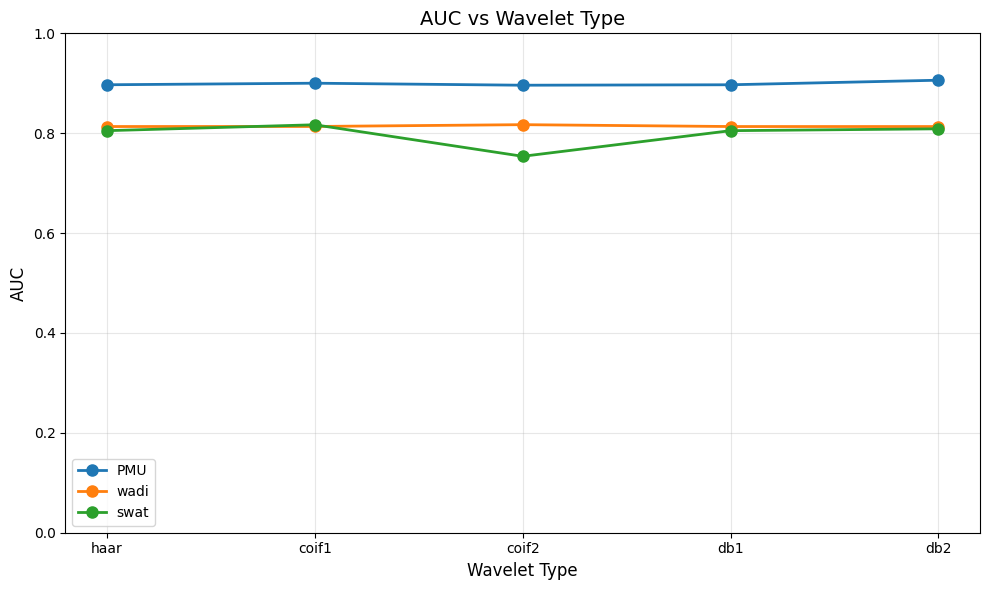

In [24]:
print("Sensitivity Analysis on Wavelet Type:")
wavelet_types = ["haar", "coif1", "coif2", "db1", "db2"]
datasets = ['PMU', 'wadi', 'swat']  

# Extract AUC values for each dataset
plt.figure(figsize=(10, 6))

for dataset in datasets:
    auc_values = []
    for wavelet in wavelet_types:
        wavelet_key = f'{wavelet}'  # Creates 'haar', 'coif1', etc.
        auc = results[wavelet_key][dataset]['AUC']
        auc_values.append(auc)
    
    plt.plot(wavelet_types, auc_values, marker='o', label=dataset, linewidth=2, markersize=8)

plt.xlabel('Wavelet Type', fontsize=12)
plt.ylabel('AUC', fontsize=12)
plt.title('AUC vs Wavelet Type', fontsize=14)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.0)  # AUC ranges from 0 to 1
plt.tight_layout()
plt.savefig('../figures/sensitivity_wavelet.png', dpi=300, bbox_inches='tight')
plt.show()

Sensitivity Analysis on Window Size:


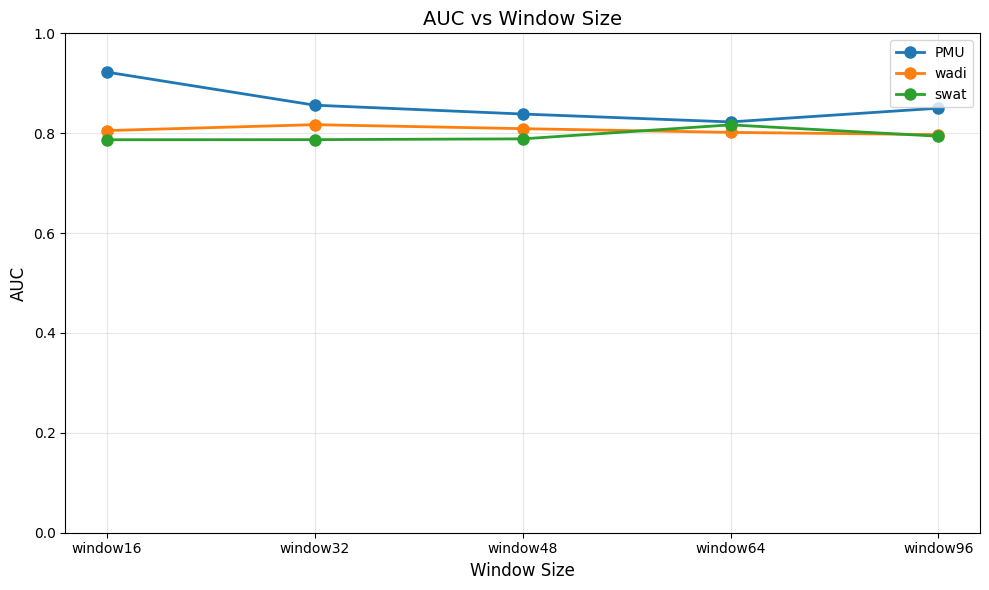

In [31]:
print("Sensitivity Analysis on Window Size:")

window_sizes = ["window16", "window32", "window48", "window64", "window96"]
datasets = ['PMU', 'wadi', 'swat']  

# Extract AUC values for each dataset
plt.figure(figsize=(10, 6))

for dataset in datasets:
    auc_values = []
    for window in window_sizes:
        window_key = f'{window}'  # Creates '16', '32', etc.
        auc = results[window_key][dataset]['AUC']
        auc_values.append(auc)
    
    plt.plot(window_sizes, auc_values, marker='o', label=dataset, linewidth=2, markersize=8)

plt.xlabel('Window Size', fontsize=12)
plt.ylabel('AUC', fontsize=12)
plt.title('AUC vs Window Size', fontsize=14)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.0)  # AUC ranges from 0 to 1
plt.tight_layout()
plt.savefig('../figures/sensitivity_window.png', dpi=300, bbox_inches='tight')
plt.show()